# Dice Probability Calculator

#### Manan Verma  
#### 20 May 2026

In [28]:
import math, random
import matplotlib.pyplot as plt
import numpy as np

**Visualizing the Probability Mass Function (PMF) for fair 6-sided dice rolls.**

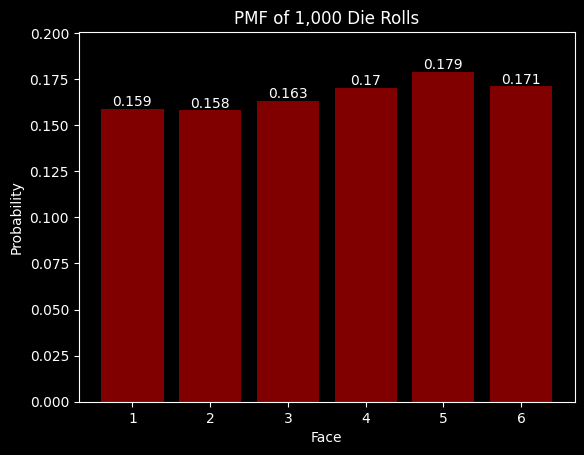

In [29]:
#Create the PMF of a fair 6 sided die

def roll_dice(num_rolls):
    """Rolls a die the specified number of times.
       Takes in as input the desired number of rolls, and outputs a list of the outcomes of those rolls"""
    rolls = []

    for i in range (num_rolls):
        rolls.append(random.randint(1, 6))
    
    return rolls

#Plot the PMF
all_rolls = roll_dice(1000)
fig, ax = plt.subplots()

values, bins, bars = plt.hist(all_rolls, bins = [0.5,1.5,2.5,3.5,4.5,5.5,6.5], density = True, color = 'maroon', rwidth = 0.8)

plt.bar_label(bars)
plt.style.use('dark_background')
plt.title('PMF of 1,000 Die Rolls')
plt.xlabel("Face")
plt.ylabel("Probability")
y_max = plt.ylim()[1]
ax.set_ylim(0, y_max + 0.0125)

plt.show()

The graph above shows the emperical (experimental) probabilities of each face of the die showing up, based on 1,000 die rolls. Ideally, since the die is fair, each face is expected to show up the same number of times (which equates to a probability of about 0.167), which clearly isn't what is shown by the graph. However, according to the **Law of Large Numbers**, as the number of independent experiments increases (where each experiment is a single die roll), the probabilities of seeing each of the faces appear will converge to their expected probabilities. Thus, as the die is rolled more and more times, the observed PMF will converge to the actual PMF.  
*Note that this law holds for every PMF and PDF.*

___

***Q: What is the expected number of rolls required to see all 6 faces of this fair die?***

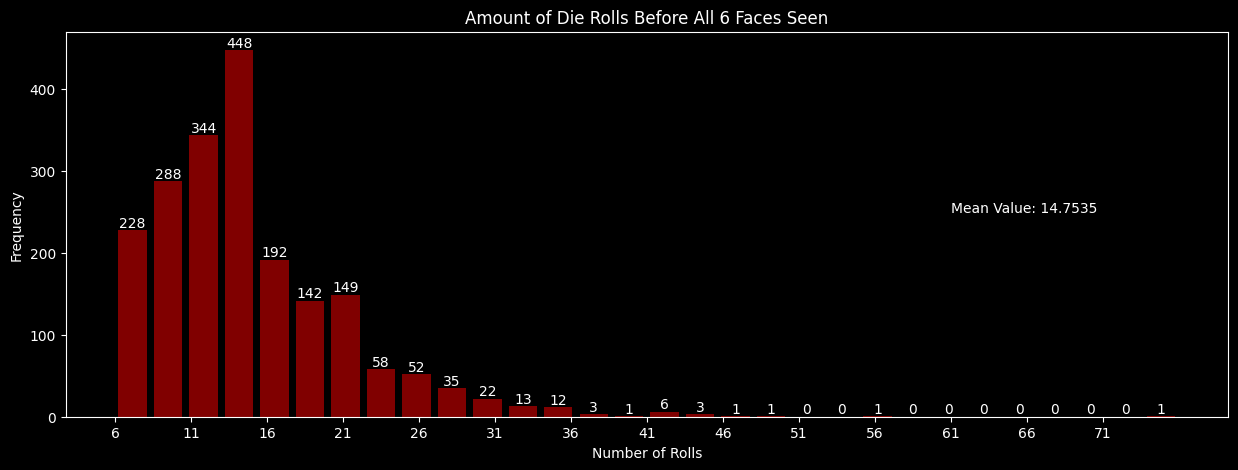

In [30]:
#Plot a histogram of the number of rolls before all 6 faces have been seen

def find_num_rolls():
    """Roll a fair die until all 6 faces have been seen
       Takes in no input, output an integer that represents the amout of rolls taken to see all six faces."""
    rolls = 0
    faces_seen = []

    while(len(faces_seen) != 6):
        current_roll = random.randint(1, 6)
        if (current_roll not in faces_seen):
            faces_seen.append(current_roll)
        rolls += 1
    
    return rolls

#Plot the Histogram
num_rolls = [find_num_rolls() for i in range(2000)]

plt.style.use('dark_background')
plt.figure(figsize = (15, 5))
values, bins, bars = plt.hist(num_rolls, bins = 30, color = 'maroon', rwidth = 0.8)
plt.bar_label(bars)
plt.title('Amount of Die Rolls Before All 6 Faces Seen')
plt.xlabel("Number of Rolls")
plt.ylabel("Frequency")
plt.xticks(np.arange(min(num_rolls), max(num_rolls), 5))
plt.text(max(num_rolls) - 15, 250, f"Mean Value: {np.mean(num_rolls)}")

plt.show()

Upon running the simulation a few times and observing the frequency distribution, it seems that, empirically, the expected number of rolls required to see all 6 faces of this die lies somewhere between 14.4 and 15.0.  
However, this problem can also be solved analytically.

To solve it, the geometric distribution will be utilized, which is a discreet probability model that quantifies the number of trials needed to achieve the first success within a set number of independent trials, given a probability of that success happening.  
In this die roll situation, a "success" can be defined as seeing a new face (i.e. a face that hasn't been rolled before), then the expected number of rolls needed before seeing each new face can be calculated and summed up in order to find the solution.

In a geometric distribution, the probability that the first success happens on the *x-th* trial, or attempt, is shown as  

$$ \textbf{P(X = x)} = (1 - p)^{(x - 1)} \cdot p $$

for probability of success $p$.  
And the expected value, or mean, for the number of trials needed for the first success is shown as  

$$ \mu = \frac{1}{p} $$

To begin, the probability of seeing a new face is $1.0$, since no faces have been seen yet. Therefore the expected number of rolls necessary to see the first new face is $\mu_{First Face} = \frac{1}{1} = 1$.

Now there are 5 faces that need to be seen, thus the probability of seeing one of those faces on any given roll is $\frac{5}{6}$, which gives an expected value for the number of rolls necessary as $\mu_{Second Face} = \frac{6}{5}$

This process is then continued for every face. To find the final solution, the expected values are simply summed up (by the linearity of the Expectation operator):  
$$\sum \mu_i = 1 + \frac{6}{5} + \frac{6}{4} + \frac{6}{3} + \frac{6}{2} + \frac{6}{1}$$

***Expected Number of Rolls = 14.7***

*<u>Generalization</u>*:  
This is known as the **Coupon Collector Problem**. If every outcome has an equal probability of showing up, then the expected value can be generalized as follows:
$$\mathbb{E}[X] = n \cdot \sum_{i = 1}^{n} \frac{1}{i}$$

___

***Q: What is the expected number of rolls required to see all 6 faces of a <u>non-fair</u> die?***

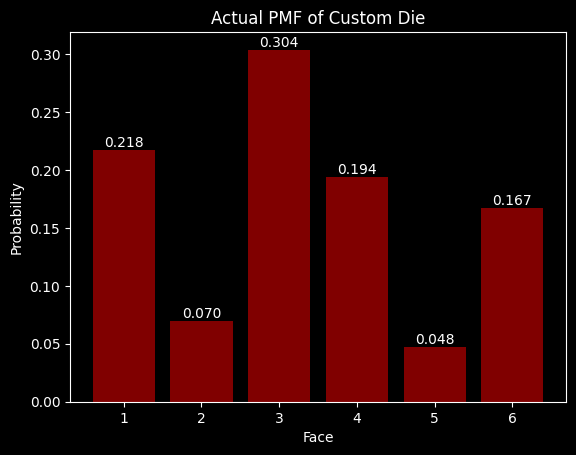

In [31]:
#Create the actual PMF of this custom die, randomly

def create_pmf():
    """Assigns each of the faces of the die to a probability, essentially creating the die's PMF.
       Takes in no input, outputs a list containing probabilities where the i-th value corresponds to the probability
       of the i-th face to show up."""
    probabilities = []

    #To create the probabilities randomly, 6 random numbers are created, then they are each normalized by their sum.
    #Thus, they are all non-zero and sum to 1
    probabilities = [random.random() for i in range (6)]
    tot = sum(probabilities)
    probabilities = [x/tot for x in probabilities]

    return probabilities

#Plot the PMF
faces = [1, 2, 3, 4, 5, 6]
probabilities = create_pmf()
plt.style.use('dark_background')
fig, ax = plt.subplots()
bars = ax.bar(x = faces, height = probabilities, width = 0.8, color = 'maroon')
plt.xlabel("Face")
plt.ylabel("Probability")
plt.title("Actual PMF of Custom Die")
ax.bar_label(bars, fmt='%.3f')

plt.show()

The expected value for the number of rolls needed to see all 6 faces can be estimated using simulation:

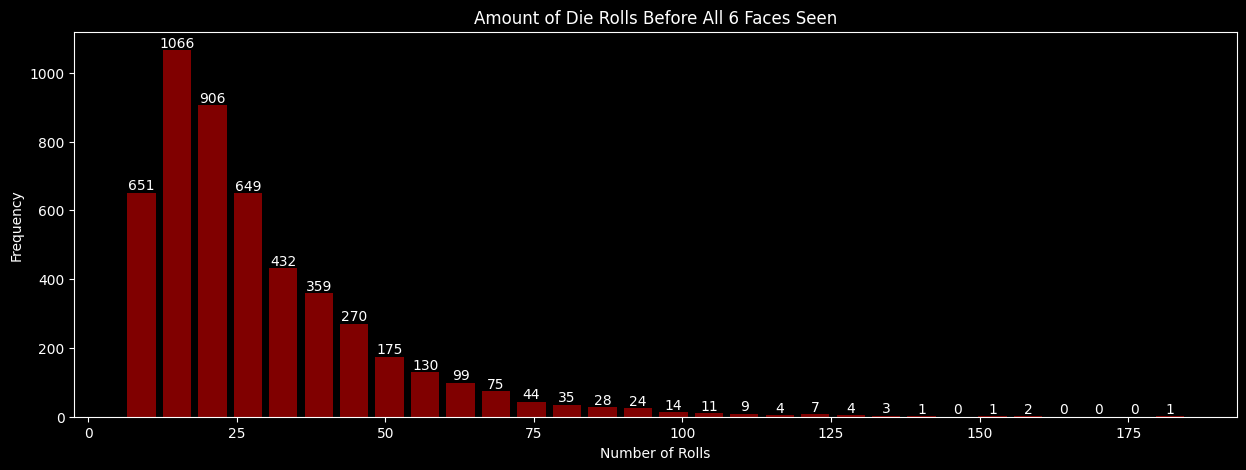

Mean Value for Number of Rolls: 28.2874


In [32]:
#Approximate the mean value for the number of rolls, given the above PMF

def find_num_rolls_unfair():
   """Roll the new, custom die until all 6 faces have been seen
      Takes in no input, output an integer that represents the amout of rolls taken to see all six faces."""
   rolls = 0
   faces_seen = []
   faces = [1, 2, 3, 4, 5, 6]

   while(len(faces_seen) != 6):
        current_roll = np.random.choice(a = faces, p = probabilities)
        if (current_roll not in faces_seen):
            faces_seen.append(current_roll)
        rolls += 1
    
   return rolls

#Plot the Histogram
num_rolls = [find_num_rolls_unfair() for i in range(5000)]

plt.style.use('dark_background')
plt.figure(figsize = (15, 5))
values, bins, bars = plt.hist(num_rolls, bins = 30, color = 'maroon', rwidth = 0.8)
plt.bar_label(bars)
plt.title('Amount of Die Rolls Before All 6 Faces Seen')
plt.xlabel("Number of Rolls")
plt.ylabel("Frequency")

plt.show()

print(f"Mean Value for Number of Rolls: {np.mean(num_rolls)}")

The previous result derived for the fair die will have to be generalized in order to analytically calculate the expected value of rolls for this new, custom die.  
The die's PMF is given, where each face $i$ has a probability of $p_i$: 
$$ \sum_{i=1}^{6} p_i = 1.0 $$
And let the random variable $T_i$ be the number of rolls before the $i$ th face is seen. Then, it follows that the total number of rolls, $T$, needed to see all six faces is:
$$T = max\{T_1, T_2,...,T_6\}$$
Thus, the problem that needs to be solved is:
$$\mathbb{E}[T]$$
To solve this, the *maximum-minimums identity* will be utilized, which states a relationship between the maximum of a set and minimums of its subsets (the linearity of the expectation operator will also be used):
$$\mathbb{E}[max\{T_1, T_2,...T_N\}] = \sum_i^N \mathbb{E}[T_i] - \sum_{i < j} \mathbb{E}[min\{T_i, T_j\}] + \sum_{i < j < k} \mathbb{E}[min\{T_i, T_j, T_k\}] - \cdots + (-1)^{N + 1}\cdot \mathbb{E}[min\{T_1, T_2,...,T_N\}]$$
where, in this case, $N = 6$ .

Note that the minimum of $T_i$ and $T_j$ is the number of rolls before seeing either face $i$ OR face $j$, and both random variables are geometrically distributed. The probability of seeing either face $i$ or face $j$ is $p_i + p_j$, where $p_i$ is the probability of seeing face $i$, etc.  
For a geometric distribution, the mean- or expected value- is given as $\mathbb{E}[X] = \frac{1}{p}$.

Therefore, the above identity can be simplified as:
$$\mathbb{E}[T] = \sum_i^6 \frac{1}{p_i} - \sum_{i<j} \frac{1}{p_i + p_j} + \sum_{i<j<k} \frac{1}{p_i + p_j + p_k} - \cdots + (-1)^7 \cdot \frac{1}{p_1 + \cdots + p_6}$$
This equation can now be implemented using code. A semi-brute-force approach is shown below, for this custom 6-sided die:

In [33]:
#Find the expected number of rolls needed to see all six faces of the non-fair die, as defined by the PMF generated above

def find_mean(probabilities):
    """Finds the expected number of rolls required to see all six faces of the non-fair die, as described in the equation above
       Takes in the list of probabilities for each face as generated above, outputs the expected number of rolls."""
    term_1 = sum(1/x for x in probabilities)

    term_2 = 0
    for i in range(5):
        for j in range(i + 1, 6):
            term_2 += 1 / (probabilities[i] + probabilities[j])

    term_3 = 0
    for i in range(4):
        for j in range(i + 1, 5):
            for k in range(j + 1, 6):
                term_3 += 1 / (probabilities[i] + probabilities[j] + probabilities[k])

    term_4 = 0
    for i in range(3):
        for j in range(i + 1, 4):
            for k in range(j + 1, 5):
                for l in range(k + 1, 6):
                    term_4 += 1 / (probabilities[i] + 
                                   probabilities[j] + 
                                   probabilities[k] +
                                   probabilities[l])
    
    term_5 = 0
    for i in range(6):
        term_5 += 1 / sum(probabilities[j] for j in range(6) if j != i)

    term_6 = 1 / sum(probabilities)

    return term_1 - term_2 + term_3 - term_4 + term_5 - term_6

mean = find_mean(probabilities)
print(f"The expected number of rolls required to observe every face of the non-fair die is {mean:.3f} rolls.")
print(f"That is an approximately {100 * abs(np.mean(num_rolls) - mean) / mean :.2f}% error between the actual and the simulation.")

The expected number of rolls required to observe every face of the non-fair die is 28.059 rolls.
That is an approximately 0.82% error between the actual and the simulation.


To find an even-more closed-form solution and for an arbitrary number of outcomes, $N$, the following identity is utilized:
$$1 - \prod_{i = 1}^N (1 - e^{-p_ix}) = \sum_i^N e^{-p_ix} - \sum_{i < j} e^{-(p_i + p_j)x} + \cdots + (-1)^{N + 1} \cdot e^{-(\sum_{i=1}^N p_i)x}$$

Then, both sides are integrated from $0$ to $\infty$, and the integral and summation can be switched since the sum is finite:
$$\int_0^{\infty} \left( 1 - \prod_{i = 1}^N (1 - e^{-p_ix}) \right) dx = \sum_i^N \int_0^{\infty} e^{-p_ix} dx - \sum_{i < j} \int_0^{\infty} e^{-(p_i + p_j)x} dx + \cdots$$
Note that
$$\int_0^{\infty} e^{-\alpha x} dx = \frac{1}{\alpha}$$
Notice, then, when the integrals are evaluated, the result derived from the maximum-minimum identity is obtained.

Thus, the final closed-form solution for the expected value is:
$$\mathbb{E}[T] = \int_0^{\infty} \left( 1 - \prod_{i = 1}^N (1 - e^{-p_ix}) \right) dx$$

*Information referenced from: https://mat.uab.cat/matmat_antiga/PDFv2014/v2014n02.pdf*